In [217]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

import re
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler

from scipy.sparse import csr_matrix, hstack

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import spacy

import scipy.stats as ss
from scipy.stats import pointbiserialr


In [2]:
reviews = pd.read_csv('BA_AirlineReviews.csv')

In [3]:
reviews.shape

(3701, 20)

In [4]:
reviews.keys()

Index(['Unnamed: 0', 'OverallRating', 'ReviewHeader', 'Name', 'Datetime',
       'VerifiedReview', 'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route',
       'DateFlown', 'SeatComfort', 'CabinStaffService', 'GroundService',
       'ValueForMoney', 'Recommended', 'Aircraft', 'Food&Beverages',
       'InflightEntertainment', 'Wifi&Connectivity'],
      dtype='object')

In [5]:
def name_pythonizer(column_name):
    # Insert underscore before capital letters that are preceded by a lowercase letter or digit
    column_name = re.sub(r'(?<=[a-z0-9])([A-Z])', r'_\1', column_name)
    
    # Convert to lowercase
    column_name = column_name.lower()
    
    # Replace dots and spaces with underscores
    column_name = column_name.replace('.', '_').replace(' ', '_')
    
    return column_name

reviews.columns = reviews.columns.map(name_pythonizer)
reviews.keys()

Index(['unnamed:_0', 'overall_rating', 'review_header', 'name', 'datetime',
       'verified_review', 'review_body', 'type_of_traveller', 'seat_type',
       'route', 'date_flown', 'seat_comfort', 'cabin_staff_service',
       'ground_service', 'value_for_money', 'recommended', 'aircraft',
       'food&beverages', 'inflight_entertainment', 'wifi&connectivity'],
      dtype='object')

In [6]:
reviews.overall_rating.describe()

count    3696.000000
mean        4.734307
std         3.175306
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max        10.000000
Name: overall_rating, dtype: float64

### Discussion about the suitability of overall_rating for a target variable 

To use Logistic Regression and/or Naive Bayes, a target variable y is needed. A hypothetical candidate for such a variable is overall_rating.  
However, before deciding to use it, it must be carefully examined. The main unknown regarding the variable is what it is derived from. Is it just a mean value of the other ratings given or is it manually inputed by the reviewer? If it is manually inputed, in how far is it corelated with the other rating features, i.e. can we consider it representative for the sentiment of the review?  
In order to answer those questions, or at least to be able to assume with high certainty, we will first check for how many rows the value of overall_rating is equal to the mean value of the rating features.   

In [8]:
#Check if overall_rating is just a mean value of the other rating columns 
reviews=pd.DataFrame(reviews)
rating_cols = [
    'seat_comfort',
    'cabin_staff_service',
    'ground_service',
    'value_for_money',
    'food&beverages',
    'inflight_entertainment',
    'wifi&connectivity'
]

# Compute row-wise mean of the listed features
calculated_mean = reviews[rating_cols].mean(axis=1)

# Compare with overall_rating (tolerance handles floating-point precision issues)
is_mean = np.isclose(reviews['overall_rating'], calculated_mean, equal_nan=True)

# Summary results
print(f"Rows where overall_rating equals the mean: {is_mean.sum()} / {len(reviews)}")

# Optional: inspect mismatches
mismatches = reviews.loc[~is_mean, ['overall_rating'] + rating_cols]


Rows where overall_rating equals the mean: 368 / 3701


Apparently, the values or overall_rating do not represent the mean value of the other ratings, which brings us to the conclusion that it was most probably manually inputed by the user. Now we have to check the correlation with the other rating columns, so that we are sure that the variable's values are meaningful compared to the other rating columns. 

In [10]:
for col in rating_cols:
    corr = reviews[['overall_rating', col]].dropna().corr().iloc[0,1]
    print(f'Correlation with {col}: {corr:.3f}')


Correlation with seat_comfort: 0.740
Correlation with cabin_staff_service: 0.723
Correlation with ground_service: 0.729
Correlation with value_for_money: 0.873
Correlation with food&beverages: 0.760
Correlation with inflight_entertainment: 0.547
Correlation with wifi&connectivity: 0.609


### Decision for overall_rating

As we can see, overall_rating is highly correlated with most of the the rating columns and positively correlated with all of them. Therefore, we can conclude that the overall_rating column can be used as a target feature.

### Check the distribution of overall_rating  

We now check the distribution of overall rating to check whether it is well-enough distributed to suit 5 distinct sentiment classes. 

In [13]:
def map_sentiment_5(x):
    if x <= 2:
        return "very_negative"
    elif x <= 4:
        return "negative"
    elif x <= 6:
        return "neutral"
    elif x <= 8:
        return "positive"
    else:
        return "very_positive"

reviews['sentiment_5'] = reviews['overall_rating'].apply(map_sentiment_5)
reviews['sentiment_5'].value_counts(normalize=True)


sentiment_5
very_negative    0.348284
positive         0.184545
negative         0.178330
very_positive    0.174277
neutral          0.114564
Name: proportion, dtype: float64

### Discussion and decision

The 5-class discretization was retained since all sentiment categories contained more than 10% of observations, ensuring sufficient representation for stable multinomial classification. Nevertheless, since the distrbution across the 5 classes is still imbalanced, a comparison between 5- and 3-class model will be made at a later stage (in the model tuning stage). For this purpose, another variable, called sentiment_3 will now be introduced.  
Note: overall_rating will not be dropped. It will only not be included in the model training.

In [15]:
def map_sentiment_3(x):
    if x <= 4:
        return "negative"
    elif x <= 6:
        return "neutral"
    else:
        return "positive"

reviews['sentiment_3'] = reviews['overall_rating'].apply(map_sentiment_3)

In [16]:
pd.set_option('display.max_colwidth', None)
display(reviews.review_body)

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   4 Hours before takeoff we received a Mail stating a cryptic message that there are disruptions to be expected as there is a limit on how many planes can leave at the same time. So did the capacity of the Heathrow Airport really hit British Airways by surprise, 4h before departure? Anyhow - we took the one hour delay so what - but then we have been forced to check in our

In [17]:
reviews.review_header

0         "Service level far worse then Ryanair"
1       "do not upgrade members based on status"
2                  "Flight was smooth and quick"
3                  "Absolutely hopeless airline"
4             "Customer Service is non existent"
                          ...                   
3696             British Airways customer review
3697             British Airways customer review
3698             British Airways customer review
3699             British Airways customer review
3700             British Airways customer review
Name: review_header, Length: 3701, dtype: object

In [18]:
reviews.review_header.value_counts(normalize=True)

review_header
British Airways customer review      0.258309
"never fly British Airways again"    0.001621
"Overall a good flight"              0.001351
"I was pleasantly surprised"         0.000811
"BA has gone downhill"               0.000811
                                       ...   
"personal space is so tight"         0.000270
"arrived reasonably promptly"        0.000270
"very professional and pleasant"     0.000270
"a fantastic flight"                 0.000270
"cannot fault the service"           0.000270
Name: proportion, Length: 2684, dtype: float64

It is very probable that old reviews have a 

In [20]:
reviews[reviews.review_header == 'British Airways customer review'].date_flown.value_counts(normalize=True)

date_flown
July 2015         0.297753
August 2015       0.275281
June 2015         0.213483
May 2015          0.089888
November 2014     0.011236
September 2014    0.011236
April 2015        0.011236
September 2020    0.005618
October 2014      0.005618
August 2014       0.005618
December 2014     0.005618
October 2015      0.005618
February 2020     0.005618
December 2015     0.005618
January 2016      0.005618
January 2018      0.005618
May 2018          0.005618
October 2018      0.005618
December 2018     0.005618
February 2018     0.005618
January 2019      0.005618
May 2019          0.005618
July 2014         0.005618
Name: proportion, dtype: float64

### Decision for review_header column
Although the dataset contains a review header field, it is excluded from the sentiment classification model due to a high proportion of repeated and non-informative titles, which would otherwise introduce noise without improving predictive performance.

In [22]:
reviews.dtypes

unnamed:_0                  int64
overall_rating            float64
review_header              object
name                       object
datetime                   object
verified_review              bool
review_body                object
type_of_traveller          object
seat_type                  object
route                      object
date_flown                 object
seat_comfort              float64
cabin_staff_service       float64
ground_service            float64
value_for_money           float64
recommended                object
aircraft                   object
food&beverages            float64
inflight_entertainment    float64
wifi&connectivity         float64
sentiment_5                object
sentiment_3                object
dtype: object

In [23]:
#Check how many reviews are verified
reviews.verified_review.value_counts(normalize=True)

verified_review
False    0.688463
True     0.311537
Name: proportion, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_36796\314705373.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ver_reviews_corr_sorted.values, y=ver_reviews_corr_sorted.index, palette='coolwarm')


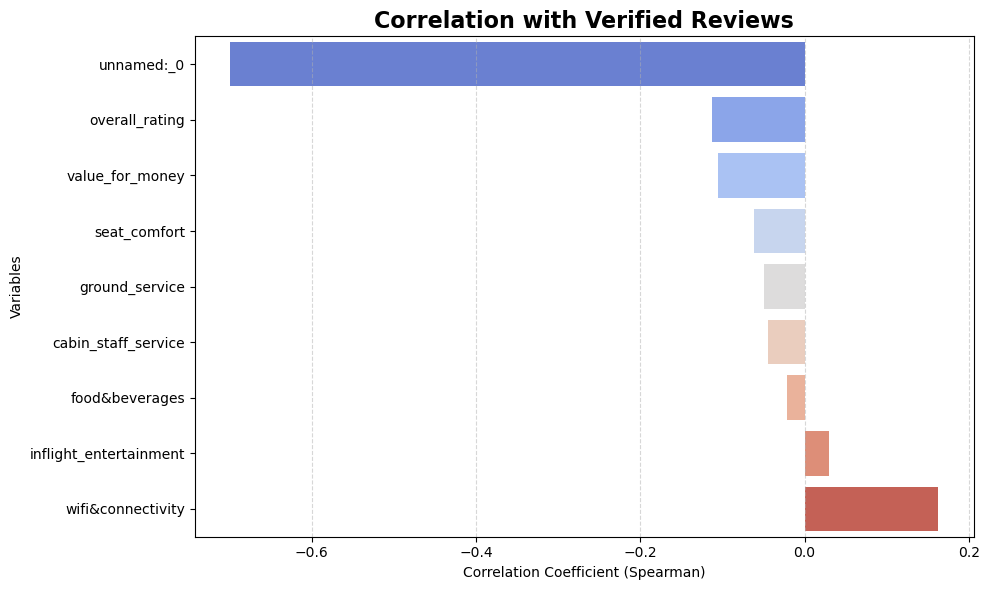

In [24]:
#Check the correlation between verified_review and the rest of the columns 
# Exclude non-numeric columns from correlation
correlations = reviews.drop(columns=['review_header', 'name', 'datetime', 'review_body', 'type_of_traveller', 'seat_type',
       'route', 'date_flown', 'recommended', 'aircraft', 'sentiment_3', 'sentiment_5']).corr(method='spearman')

# Get only correlations with 'life_expectancy'
ver_reviews_corr = correlations['verified_review'].drop('verified_review')

# Sort correlations
ver_reviews_corr_sorted = ver_reviews_corr.sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=ver_reviews_corr_sorted.values, y=ver_reviews_corr_sorted.index, palette='coolwarm')

plt.title('Correlation with Verified Reviews', fontsize=16, weight='bold')
plt.xlabel('Correlation Coefficient (Spearman)')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


### Decision for verified_review column 
Although the dataset contains a verification flag, this attribute is excluded from the sentiment analysis model because the verification criteria are not transparent and the feature does not directly reflect customer sentiment, which could otherwise introduce uncontrolled bias. The correlation of the feature with the other numeric features was proven to be neglectable, hardly excedding |0.2|,calculated using the Spearman correlation coefficient

In [26]:
reviews = reviews.drop(columns=['verified_review', 'review_header'])

In [27]:
reviews.describe()

,unnamed:_0,overall_rating,seat_comfort,cabin_staff_service,ground_service,value_for_money,food&beverages,inflight_entertainment,wifi&connectivity
count,3701.000000,3696.000000,3585.000000,3574.000000,2855.000000,3700.000000,3315.000000,2551.000000,609.000000
mean,1850.000000,4.734307,2.875314,3.254057,2.784238,2.688378,2.713122,2.646021,1.924466
std,1068.531001,3.175306,1.362081,1.489709,1.457058,1.471887,1.437092,1.398509,1.352705
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,925.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1850.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000
75%,2775.000000,8.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000,3.000000
max,3700.000000,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [28]:
reviews.seat_type.value_counts(normalize=True)

seat_type
Economy Class      0.520952
Business Class     0.323871
Premium Economy    0.097594
First Class        0.057583
Name: proportion, dtype: float64

In [29]:
reviews.type_of_traveller.value_counts(normalize=True)

type_of_traveller
Couple Leisure    0.341297
Solo Leisure      0.304096
Business          0.218771
Family Leisure    0.135836
Name: proportion, dtype: float64

In [30]:
reviews.aircraft.value_counts()

aircraft
A320                     366
Boeing 777               272
Boeing 747-400           182
A380                     166
Boeing 777-200           125
                        ... 
A319 / Boeing 787-9        1
Boeing 747-400 / A319      1
A320 / Boeing 747-400      1
Boeing 777 / A380          1
Airbus 319                 1
Name: count, Length: 202, dtype: int64

### Decision for aircraft 
“The aircraft model attribute was excluded from the sentiment analysis model, as it represents contextual information rather than an explicit expression of customer sentiment and would therefore not contribute meaningfully to sentiment prediction. Moreover, seat comofort, inflight entertainment and food and beverages are already explicitly rated.""

In [32]:
reviews = reviews.drop(columns=['aircraft'])

In [33]:
reviews['unnamed:_0']

0          0
1          1
2          2
3          3
4          4
        ... 
3696    3696
3697    3697
3698    3698
3699    3699
3700    3700
Name: unnamed:_0, Length: 3701, dtype: int64

### Decision for route 

The route is excluded from the model as it also represents rather contextual information than an explicit expression of sentiment analysis.

In [35]:
reviews = reviews.drop(columns=['route'])

### Decision for unnamed:_0 
This column represents only the index of the observation and thus brings no additional value to the model. Therefore, it is dropped.

In [37]:
reviews = reviews.drop(columns=['unnamed:_0'])

In [38]:
reviews.keys()

Index(['overall_rating', 'name', 'datetime', 'review_body',
       'type_of_traveller', 'seat_type', 'date_flown', 'seat_comfort',
       'cabin_staff_service', 'ground_service', 'value_for_money',
       'recommended', 'food&beverages', 'inflight_entertainment',
       'wifi&connectivity', 'sentiment_5', 'sentiment_3'],
      dtype='object')

In [39]:
reviews.name.value_counts(dropna=False)

name
David Ellis       42
Clive Drake       32
E Smyth           30
R Vines           14
Richard Hodges    13
                  ..
A Thadaram         1
C Norton           1
A George           1
B Palmer           1
C Volz             1
Name: count, Length: 2906, dtype: int64

In [40]:
reviews.seat_type.value_counts(normalize=True, dropna=False)

seat_type
Economy Class      0.520670
Business Class     0.323696
Premium Economy    0.097541
First Class        0.057552
NaN                0.000540
Name: proportion, dtype: float64

In [41]:
reviews.type_of_traveller.value_counts(normalize=True, dropna=False)

type_of_traveller
Couple Leisure    0.270197
Solo Leisure      0.240746
NaN               0.208322
Business          0.173196
Family Leisure    0.107539
Name: proportion, dtype: float64

### Discussion about name, type_of_traveller and seat_type
The variables name, type_of_traveller, and seat_type are excluded from the sentiment classification model. The reviewer name serves only as an identifier and does not contain predictive information. The traveller type and seat type represent contextual or demographic attributes rather than direct expressions of sentiment. Including these variables could introduce bias and shift the model’s focus away from linguistic and evaluative signals, which are central to sentiment analysis.

In [43]:
reviews = reviews.drop(columns=['name', 'type_of_traveller', 'seat_type'])

In [44]:
#Ensure date_flown and datetime are in datetime format 
reviews['date_flown'] = pd.to_datetime(reviews['date_flown'], errors='coerce')
reviews['datetime'] = pd.to_datetime(reviews['datetime'], errors='coerce')


C:\Users\user\AppData\Local\Temp\ipykernel_36796\1157841515.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reviews['date_flown'] = pd.to_datetime(reviews['date_flown'], errors='coerce')


In [45]:
#Investigation of date_flown
reviews.date_flown.value_counts(normalize=True, dropna=False)

date_flown
NaT           0.210213
2015-08-01    0.022426
2015-09-01    0.021075
2015-11-01    0.017833
2017-04-01    0.017563
                ...   
2014-11-01    0.000540
2014-10-01    0.000270
2020-06-01    0.000270
2014-08-01    0.000270
2014-07-01    0.000270
Name: proportion, Length: 113, dtype: float64

### Discussion about date_flown 

Before anything is conducted on the variable date_flown, we must firstly examine the 21% missing values. For this reason, we will focus on the relationship between the missing values of date_flown and the rest of the features. 

| Variable type    | Measure             |
| ---------------- | ------------------- |
| Rating (1–5)     | Point-biserial      |
| Category         | Cramér’s V          |
| Ordinal category | Spearman (optional) |


In [47]:
reviews['date_flown'].isna().mean() * 100

21.02134558227506

In [48]:
reviews['date_flown_missing'] = reviews['date_flown'].isna().astype(int)

In [49]:
reviews.date_flown_missing

0       0
1       0
2       0
3       0
4       0
       ..
3696    1
3697    1
3698    1
3699    1
3700    1
Name: date_flown_missing, Length: 3701, dtype: int32

In [50]:
#Overview of the data entries with missing values for date_flown
reviews[reviews.date_flown.isna()].drop(columns=['review_body', 'sentiment_5', 'sentiment_3'])

,overall_rating,datetime,date_flown,seat_comfort,cabin_staff_service,ground_service,value_for_money,recommended,food&beverages,inflight_entertainment,wifi&connectivity,date_flown_missing
2846,3.0,NaT,NaT,3.0,2.0,2.0,3.0,no,2.0,NaN,NaN,1
2924,4.0,2015-06-12,NaT,5.0,2.0,NaN,1.0,no,2.0,1.0,NaN,1
2925,5.0,2015-06-12,NaT,3.0,4.0,NaN,3.0,no,3.0,4.0,NaN,1
2926,8.0,2015-06-12,NaT,3.0,5.0,NaN,4.0,yes,NaN,4.0,1.0,1
2927,8.0,2015-06-11,NaT,3.0,5.0,NaN,4.0,yes,5.0,5.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3696,1.0,2012-08-29,NaT,3.0,1.0,NaN,3.0,no,2.0,NaN,NaN,1
3697,9.0,2012-08-28,NaT,4.0,5.0,NaN,3.0,yes,4.0,NaN,NaN,1
3698,5.0,2011-10-12,NaT,NaN,NaN,NaN,4.0,yes,NaN,NaN,NaN,1
3699,4.0,2011-10-11,NaT,1.0,3.0,NaN,1.0,no,5.0,NaN,NaN,1


(array([ 91.,  67.,  56.,  53.,  58.,  51.,  91.,  92., 101., 113.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

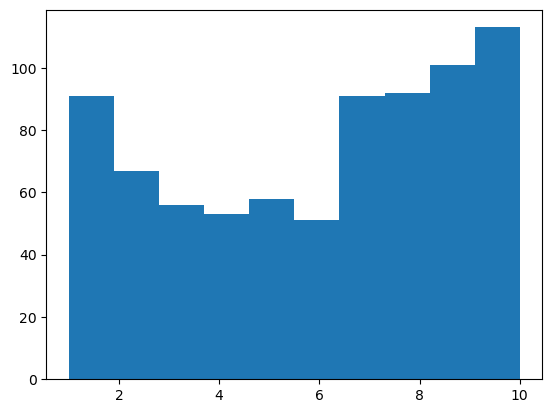

In [51]:
plt.hist(reviews[reviews.date_flown.isna()]['overall_rating'], bins=10)

Calculate the correlation following the methods in the table above

In [53]:
rating_cols = ['overall_rating', 'seat_comfort', 'cabin_staff_service', 'ground_service', 'value_for_money', 'food&beverages', 'inflight_entertainment', 'wifi&connectivity'] 
target = 'date_flown_missing'
results = []

for col in rating_cols:
    # drop rows with NA in either variable
    subset = reviews[[target, col]].dropna()
    
    r, p = pointbiserialr(subset[target], subset[col])
    
    results.append({
        'variable': col,
        'correlation': r,
        'p_value': p,
        'n': len(subset)
    })

results_df = pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False)

print(results_df)


                 variable  correlation       p_value     n
4         value_for_money     0.209717  4.744348e-38  3700
0          overall_rating     0.199772  1.399176e-34  3696
5          food&beverages     0.144014  7.941019e-17  3315
1            seat_comfort     0.136148  2.675042e-16  3585
2     cabin_staff_service     0.104561  3.705244e-10  3574
7       wifi&connectivity    -0.027739  4.944366e-01   609
3          ground_service    -0.010077  5.904386e-01  2855
6  inflight_entertainment    -0.001744  9.298237e-01  2551


In [54]:
reviews.date_flown_missing

0       0
1       0
2       0
3       0
4       0
       ..
3696    1
3697    1
3698    1
3699    1
3700    1
Name: date_flown_missing, Length: 3701, dtype: int32

### Decision about date_flown, introducing new time-lag feature and feature derivation

#### Discussion about missingness
Missingness analysis indicated weak association (|r| < 0.2) with rating variables, suggesting approximately random missingness. Therefore, median imputation is applied to temporal components prior to feature derivation, preserving distributional characteristics while avoiding systematic bias.

#### Discussion about creating a time-lag feature 
A time-delay feature between flight date and review date was considered as a proxy for review impulsiveness. Impulsive reviews can typically be assumed to be written within a narrow temporal window (approximately 3 days, up to 5 days) following the flight. However, in the available dataset, flight dates are recorded only at month-level granularity. Converting it to date-level granularity would introduce an uncertainty of up to ±15 days. This uncertainty exceeds the temporal window required to reliably distinguish impulsive from reflective reviews. Consequently, the feature is deemed non-identifiable with respect to the intended construct and is excluded from the final model.

#### Discussion about introducing new features substituting date_flown and datetime
The features date_flown and datetime are hardly usable in their current form. There are several reasons for that:  
1) They have different granularities (month-level and day-level)
2) The specific publication date of the review can hardly contribute to the idea of the model, thus perhaps only overcomplicating the model
3) From a domain-specific perspective, the month flown can be assumed to be of greater importance than the year flown. However, as this can not be truly estimated at his point, it makes sense keeping them both. Still, they will be separated in the features flight_year and flight_month. Moreover, as the seasonality can be supposed to be even more important than the month, another feature called flight_season will be introduced, which differentiates between the four seasons winter, spring, summer and autumn.


In [56]:
reviews['flight_year'] = reviews['date_flown'].dt.year
reviews['flight_month'] = reviews['date_flown'].dt.month


In [57]:
# Create imputer (median is chosen as it is robust for ratings)
imputer = SimpleImputer(strategy='median')

# Fit and transform
reviews[['flight_year', 'flight_month']] = imputer.fit_transform(reviews[['flight_year', 'flight_month']])
reviews[['flight_year', 'flight_month']]

,flight_year,flight_month
0,2023.0,11.0
1,2023.0,11.0
2,2023.0,11.0
3,2022.0,12.0
4,2023.0,11.0
...,...,...
3696,2017.0,7.0
3697,2017.0,7.0
3698,2017.0,7.0
3699,2017.0,7.0


In [58]:
# Creation of flight_season

'''
Seasons are defined as follows in the next line:
Winter: December, January, February
Spring: March, April, May
Summer: June, July, August
Autumn: September, October, November
At this point, potential differences between the meteorological and tourist-perspective seasonality will be neglected
'''
reviews['flight_season'] = reviews['flight_month'] % 12 // 3

#Check the results
reviews[['flight_year', 'flight_month', 'flight_season']]

,flight_year,flight_month,flight_season
0,2023.0,11.0,3.0
1,2023.0,11.0,3.0
2,2023.0,11.0,3.0
3,2022.0,12.0,0.0
4,2023.0,11.0,3.0
...,...,...,...
3696,2017.0,7.0,2.0
3697,2017.0,7.0,2.0
3698,2017.0,7.0,2.0
3699,2017.0,7.0,2.0


### Special treatment of the newly created columns 'flight_year', 'flight_month', 'flight_season'

flight_year will be treated as a numerical column due to the linear meaning of the values (2020, 2021, 2022, etc.)  
flight_season will be treated as a categorical feature and will be encoded accordingly.  
flight_month will be cyclically encoded, which means that its values will be transformed with sine and cosine. 

In [60]:
def add_cyclical_month_features(df):
    df["month_sin"] = np.sin(2 * np.pi * df["flight_month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["flight_month"] / 12)
    return df

reviews = add_cyclical_month_features(reviews)


In [61]:
#check results 
reviews[['month_sin', 'month_cos']]

,month_sin,month_cos
0,-5.000000e-01,0.866025
1,-5.000000e-01,0.866025
2,-5.000000e-01,0.866025
3,-2.449294e-16,1.000000
4,-5.000000e-01,0.866025
...,...,...
3696,-5.000000e-01,-0.866025
3697,-5.000000e-01,-0.866025
3698,-5.000000e-01,-0.866025
3699,-5.000000e-01,-0.866025


In [62]:
reviews.keys()

Index(['overall_rating', 'datetime', 'review_body', 'date_flown',
       'seat_comfort', 'cabin_staff_service', 'ground_service',
       'value_for_money', 'recommended', 'food&beverages',
       'inflight_entertainment', 'wifi&connectivity', 'sentiment_5',
       'sentiment_3', 'date_flown_missing', 'flight_year', 'flight_month',
       'flight_season', 'month_sin', 'month_cos'],
      dtype='object')

In [63]:
reviews['food&beverages']

0       NaN
1       1.0
2       4.0
3       NaN
4       1.0
       ... 
3696    2.0
3697    4.0
3698    NaN
3699    5.0
3700    5.0
Name: food&beverages, Length: 3701, dtype: float64

In [64]:
reviews.recommended.value_counts(dropna=False)

recommended
no     2203
yes    1498
Name: count, dtype: int64

In [65]:
reviews.datetime.value_counts(normalize=True, dropna=False)

datetime
NaT           0.204539
2015-01-19    0.007025
2014-11-20    0.004864
2014-10-28    0.003783
2015-01-11    0.003242
                ...   
2019-10-24    0.000270
2019-10-26    0.000270
2017-04-08    0.000270
2019-11-07    0.000270
2011-10-09    0.000270
Name: proportion, Length: 1442, dtype: float64

In [66]:
reviews.date_flown.equals(reviews.datetime)

False

In [67]:
mask_diff = reviews['date_flown'] != reviews['datetime']
mask_diff.sum()


3701

In [68]:
reviews.shape

(3701, 20)

In [69]:
reviews.keys()

Index(['overall_rating', 'datetime', 'review_body', 'date_flown',
       'seat_comfort', 'cabin_staff_service', 'ground_service',
       'value_for_money', 'recommended', 'food&beverages',
       'inflight_entertainment', 'wifi&connectivity', 'sentiment_5',
       'sentiment_3', 'date_flown_missing', 'flight_year', 'flight_month',
       'flight_season', 'month_sin', 'month_cos'],
      dtype='object')

In [70]:
same_year_month = (
    reviews['date_flown'].dt.to_period('M') ==
    reviews['datetime'].dt.to_period('M')
)

same_year_month.mean() * 100


43.6908943528776

### Treatment of 'recommended' feature  

The feature contains only values "yes" and 'no'. The feature will then be treated as the rest of the features, as discussed in the following passage.
It is worth noting that the values 'yes' and 'no' are not going to be numerically encoded to 0 and 1 because this would add a misleading numerical distance.

In [72]:
# Normalize text (defensive)
reviews['recommended'] = (
    reviews['recommended']
    .str.strip()
    .str.lower()
    .map({'yes': 'yes', 'no': 'no'})
)

### Feature Encoding

A feature encoding pipeline is created, which treats different cases separately.

All text reviews (from the column review_body) will firstly be processed for negation and multipolarity detection and are then going to be vectorized with TF-IDF.  

The dataset includes multiple reviewer-provided rating features (referred to as rating_columns) defined on a discrete ordinal scale from 1 to 5, with a substantial proportion of missing values. Missingness in these variables is not random, as reviewers may selectively rate only certain aspects. Consequently, numerical imputation strategies (e.g., mean or median imputation) were avoided, since they introduce artificial values, distort the semantic meaning of ratings, and violate model assumptions.  

Instead, missing values were modeled explicitly as a separate category. Each rating feature was treated as a categorical variable with the domain 
{1,2,3,4,5,missing}. This preserves the distinction between expressed evaluations and the absence of an evaluation, allowing missingness itself to carry predictive information.   

Important Note: The feature flight_season is a categorical feature, even though not a rating one. This is why it will be treated separately, but not necessarily differently.   

All rating features plus flight_season were encoded using one-hot encoding, yielding binary indicator variables for each rating level and for the missing category. This encoding avoids imposing unjustified metric or linearity assumptions on ordinal ratings and is compatible with both Logistic Regression and Naive Bayes classifiers. In Logistic Regression, this allows each rating level to contribute independently to the log-odds of the target class, while in Naive Bayes it enables straightforward estimation of class-conditional probabilities for categorical features.  
 
The numerical columns 'flight_year', 'month_sin', 'month_cos' will be encoded with a simple Standard scaler.  


The target variables sentiment_5 and sentiment_3 will be additionally encoded with LabelEncoder.
#### Differentiation between logistic regression and multinomial NB  
Multinomial NB (MNB) is known to not work with negative values. For this reason, the variables month_sin and month_cos will only be used for Logistic Regression (LR). MNB will instead use the variable flight_month, which will in this case be encoded with OneHot encoding.

In [74]:
#Definition of column groups with special differentiation between LR and MNB 

text_column = "review_body"

rating_columns = [
    'seat_comfort',
    'cabin_staff_service',
    'ground_service',
    'value_for_money',
    'food&beverages',
    'inflight_entertainment',
    'wifi&connectivity',
    'recommended'
]

categorical_time_nb = ['flight_season', 'flight_month']   # For NB
categorical_time_lr = ['flight_season']                   # For Logistic

numeric_time_nb = ['flight_year']
numeric_time_lr = ['flight_year', 'month_sin', 'month_cos']



In [75]:
#Ensuring all rating columns' missing values are imputed with 'missing'
reviews[rating_columns] = reviews[rating_columns].fillna('missing').astype(str)


### Creation of a text preprocessor (negation and multipolarity handling)

In [77]:
# Load English model
nlp = spacy.load("en_core_web_sm")

class TextPreprocessor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        processed = []
        
        for text in X:
            if pd.isna(text):
                processed.append("")
                continue
            
            doc = nlp(text.lower())
            tokens = []
            negated_tokens = set()
            
            # Detect negations using dependency parsing
            for token in doc:
                if token.dep_ == "neg":
                    head = token.head
                    negated_tokens.add(head.i)
            
            for token in doc:
                
                # Skip stopwords and punctuation
                if token.is_stop or token.is_punct:
                    continue
                
                lemma = token.lemma_
                
                # Apply negation marking
                if token.i in negated_tokens:
                    lemma = "NEG_" + lemma
                
                # Keep only content words
                if token.pos_ in ["NOUN", "VERB", "ADJ", "ADV"]:
                    tokens.append(lemma)
            
            # Contrast marker detection
            if any(token.text in ["but", "however", "although"] for token in doc):
                tokens.append("CONTRAST")
            
            processed.append(" ".join(tokens))
        
        return processed

        
    def get_feature_names_out(self, input_features=None):
        return input_features


### Combined Encoding Preprocessors for LR and MNB

In [79]:
#For LR
preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            'text',
            Pipeline([
                ('neg_multi', TextPreprocessor()),
                ('tfidf', TfidfVectorizer())
            ]),
            text_column
        ),
        (
            'ratings',
            OneHotEncoder(handle_unknown='ignore'),
            rating_columns
        ),
        (
            'season',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_time_lr
        ),
        (
            'numeric_time',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())
            ]),
            numeric_time_lr
        )
    ]
)


In [80]:
#For MNB 
preprocessor_nb = ColumnTransformer(
    transformers=[
        (
            'text',
            Pipeline([
                ('neg_multi', TextPreprocessor()),
                ('tfidf', TfidfVectorizer())
            ]),
            text_column
        ),
        (
            'ratings',
            OneHotEncoder(handle_unknown='ignore'),
            rating_columns
        ),
        (
            'time',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_time_nb
        ),
        (
            'numeric_time',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())
            ]),            
            numeric_time_nb
        )
    ]
)


In [81]:
#Encodes the target variables with LabelEncoder 

# 5-class encoding
le_5 = LabelEncoder()
y_5 = le_5.fit_transform(reviews['sentiment_5'])

# 3-class encoding
le_3 = LabelEncoder()
y_3 = le_3.fit_transform(reviews['sentiment_3'])


In [230]:
y_5

array([3, 0, 2, ..., 1, 0, 0])

In [234]:
reviews['sentiment_5']

0       very_negative
1            negative
2            positive
3       very_negative
4       very_negative
            ...      
3696    very_negative
3697    very_positive
3698          neutral
3699         negative
3700         negative
Name: sentiment_5, Length: 3701, dtype: object

In [82]:
print(reviews.columns)

Index(['overall_rating', 'datetime', 'review_body', 'date_flown',
       'seat_comfort', 'cabin_staff_service', 'ground_service',
       'value_for_money', 'recommended', 'food&beverages',
       'inflight_entertainment', 'wifi&connectivity', 'sentiment_5',
       'sentiment_3', 'date_flown_missing', 'flight_year', 'flight_month',
       'flight_season', 'month_sin', 'month_cos'],
      dtype='object')


In [83]:
#Select feature columns for LR and MNB 
feature_columns_lr = (
    [text_column] +
    rating_columns +
    categorical_time_lr +
    numeric_time_lr
)

feature_columns_nb = (
    [text_column] +
    rating_columns +
    categorical_time_nb +
    numeric_time_nb
)


In [84]:
# Performs train test split separately for LR and MNB 
X_lr = reviews[feature_columns_lr]
X_nb = reviews[feature_columns_nb]

# 5-class
X_train_lr_5, X_test_lr_5, y_train_5, y_test_5 = train_test_split(
    X_lr, y_5, test_size=0.2, random_state=42, stratify=y_5
)

X_train_nb_5, X_test_nb_5, _, _ = train_test_split(
    X_nb, y_5, test_size=0.2, random_state=42, stratify=y_5
)

# 3-class
X_train_lr_3, X_test_lr_3, y_train_3, y_test_3 = train_test_split(
    X_lr, y_3, test_size=0.2, random_state=42, stratify=y_3
)

X_train_nb_3, X_test_nb_3, _, _ = train_test_split(
    X_nb, y_3, test_size=0.2, random_state=42, stratify=y_3
)


### Actual pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

def train_and_evaluate(
    X_train_lr, X_test_lr,
    X_train_nb, X_test_nb,
    y_train, y_test,
    target_name
):
    
    # Logistic Regression
    pipeline_lr = Pipeline([
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(max_iter=1000))
    ])
    
    pipeline_lr.fit(X_train_lr, y_train)
    y_pred_lr = pipeline_lr.predict(X_test_lr)
    
    print(f"\nTarget: {target_name}")
    print("Model: Logistic Regression")
    print(classification_report(y_test, y_pred_lr))
    
    
    # Multinomial NB
    pipeline_nb = Pipeline([
        ('preprocessor', preprocessor_nb),
        ('classifier', MultinomialNB())
    ])
    
    pipeline_nb.fit(X_train_nb, y_train)
    y_pred_nb = pipeline_nb.predict(X_test_nb)
    
    print("Model: Multinomial Naive Bayes")
    print(classification_report(y_test, y_pred_nb))


In [87]:
def train_and_evaluate(
    X_train_lr, X_test_lr,
    X_train_nb, X_test_nb,
    y_train, y_test,
    target_name
):
    
    # Logistic Regression
    pipeline_lr = Pipeline([
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(max_iter=3000))
    ])
    
    pipeline_lr.fit(X_train_lr, y_train)
    y_pred_lr = pipeline_lr.predict(X_test_lr)
    
    print(f"\nTarget: {target_name}")
    print("Model: Logistic Regression")
    print(classification_report(y_test, y_pred_lr))
    
    
    # Multinomial NB
    pipeline_nb = Pipeline([
        ('preprocessor', preprocessor_nb),
        ('classifier', MultinomialNB())
    ])
    
    pipeline_nb.fit(X_train_nb, y_train)
    y_pred_nb = pipeline_nb.predict(X_test_nb)
    
    print("Model: Multinomial Naive Bayes")
    print(classification_report(y_test, y_pred_nb))
    
    return pipeline_lr, pipeline_nb


In [88]:
pipeline_lr_5, pipeline_nb_5 = train_and_evaluate(
    X_train_lr_5, X_test_lr_5,
    X_train_nb_5, X_test_nb_5,
    y_train_5, y_test_5,
    "Sentiment 5-Class"
)

pipeline_lr_3, pipeline_nb_3 = train_and_evaluate(
    X_train_lr_3, X_test_lr_3,
    X_train_nb_3, X_test_nb_3,
    y_train_3, y_test_3,
    "Sentiment 3-Class"
)



Target: Sentiment 5-Class
Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.48      0.45      0.47       132
           1       0.50      0.33      0.40        85
           2       0.64      0.74      0.69       137
           3       0.78      0.84      0.81       258
           4       0.77      0.76      0.77       129

    accuracy                           0.68       741
   macro avg       0.64      0.62      0.63       741
weighted avg       0.67      0.68      0.67       741

Model: Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.51      0.17      0.25       132
           1       0.50      0.01      0.02        85
           2       0.59      0.78      0.68       137
           3       0.64      0.97      0.77       258
           4       0.79      0.77      0.78       129

    accuracy                           0.65       741
   macro avg       0.61      0.54      0.50   

C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Discussion of obtained results 

The obtained results from the classification report show a class imbalanced classification success.  
Generally, the 3-class classification models perform better than the 5-class, which is normal and expected due to the increased complexity of the 5-class segmentation.  
The logistic regression model shows very strong performance on classes 3 and 4, decent on class 2 and weak on classes 0 and 1. This may indicate a class boundary problem, not necessarily a model one.  
The NB model collapses towards dominant classes. Apparently, it is almost never able to predict class 1.   
The 3-class models are discarded as they were created for comparison only. It is interesting to note that the 5-class LR tends to predict the "neutral" class better than the 3-class model.  
As for the 5-class NB model, it is obviosuly performing much worse than the LR in classes 0 and 1. Even though it has comparable statistics in the other 3 classes, the LR model seems easier to refine, as the high prediction imbalance in the NB model signals for a potentially big problem with it.  
At this point, I decide to develop only the LR model further. Its performance will be evaluated in more details with the following:  
1) It will be checked whether the model learns sensible words, which lead to the sentiment classification. In this way, the text preprocessing part will be checked.
2) The top words per class will be looked into. It may be the case that the “mild” classes (mild positive and mild negative) overlap with the “very” classes (very positive, very negative)
3) It will be checked whether the numeric rating features are not actually dominating. It is important that the text feature(s) are also used and not “sidelined” by the model.


In [90]:
#Retrain the model to be sure it's aligned  
pipeline_lr_5 = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=3000))
])

pipeline_lr_5.fit(X_train_lr_5, y_train_5)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('neg_multi',
                                                                   TextPreprocessor()),
                                                                  ('tfidf',
                                                                   TfidfVectorizer())]),
                                                  'review_body'),
                                                 ('ratings',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['seat_comfort',
                                                   'cabin_staff_service',
                                                   'ground_service',
                                                   'value_for_money',
                                                   'food&beverages',
                                                   'inflight_entertainment',
                                                   'wifi&connectivity',
                                                   'recommended']),
                                                 ('season',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['flight_season']),
                                                 ('numeric_time',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['flight_year', 'month_sin',
                                                   'month_cos'])])),
                ('classifier', LogisticRegression(max_iter=3000))])

In [91]:
# Extract feature importance for LR_5 

 # Access fitted components
    #preprocessor = pipeline_lr_5.named_steps['preprocessor']
    #model = pipeline_lr_5.named_steps['classifier']
    
# 1️⃣ Get feature names directly from ColumnTransformer
feature_names = pipeline_lr_5.named_steps['preprocessor'].get_feature_names_out()
    
    # 2️⃣ Clean transformer prefixes (optional but recommended)
clean_feature_names = [
    name.split("__", 1)[1] if "__" in name else name
    for name in feature_names
]
    
    # 3️⃣ Reconstruct original class labels
class_labels = le_5.inverse_transform(pipeline_lr_5.named_steps['classifier'].classes_)
    
    # 4️⃣ Build coefficient DataFrame
coef_df = pd.DataFrame(
    pipeline_lr_5.named_steps['classifier'].coef_,
    columns=clean_feature_names,
    index=class_labels
)
    
coef_df

,00am,00pm,01d,01f,03a,10,1000each,1000us,100th,10a,...,wifi&connectivity_missing,recommended_no,recommended_yes,flight_season_0.0,flight_season_1.0,flight_season_2.0,flight_season_3.0,flight_year,month_sin,month_cos
negative,-0.001149,-0.022019,-0.001540,-0.001540,0.107253,-0.048397,-0.057564,-0.003905,-0.000040,-0.019480,...,0.110968,1.039195,-0.932226,0.021762,-0.147633,0.099009,0.133831,-0.102425,0.016656,0.121127
neutral,0.206959,-0.000866,-0.011241,-0.011241,-0.019808,-0.005439,-0.003152,-0.000078,-0.000309,-0.027063,...,0.015795,-0.166243,0.312491,0.248471,-0.021714,-0.175027,0.094518,-0.016957,-0.021762,-0.317733
positive,-0.184128,-0.000078,-0.035398,-0.035398,-0.005856,-0.000581,-0.000146,-0.000012,-0.004215,0.264399,...,0.068772,-1.043614,0.962258,0.004260,-0.071117,0.078894,-0.093393,-0.495241,0.301199,-0.202781
very_negative,-0.000197,0.022992,-0.000253,-0.000253,-0.081277,0.054493,0.060992,0.004010,-0.000011,0.018290,...,-0.221377,1.270492,-1.296267,-0.118666,-0.087875,0.138470,0.042296,0.420212,0.104414,0.229010
very_positive,-0.021485,-0.000029,0.048432,0.048432,-0.000312,-0.000077,-0.000130,-0.000015,0.004575,-0.236146,...,0.025841,-1.099830,0.953745,-0.155828,0.328339,-0.141346,-0.177252,0.194410,-0.400507,0.170377


In [92]:
# Extract top features per class 
def top_features_per_class(coef_df, top_n=20):
    
    for cls in coef_df.index:
        print(f"\nClass: {cls}")
        print("Top positive predictors:")
        print(
            coef_df.loc[cls]
                   .sort_values(ascending=False)
                   .head(top_n)
        )

top_features_per_class(coef_df, top_n=20)



Class: negative
Top positive predictors:
recommended_no           1.039195
staff                    0.837393
effort                   0.835175
disappointed             0.814045
kid                      0.788168
give                     0.769382
twice                    0.751326
toilet                   0.743731
indifferent              0.723084
thing                    0.712989
ground_service_1.0       0.711615
child                    0.683951
way                      0.683373
coach                    0.640704
awful                    0.636632
food&beverages_1.0       0.634206
travel                   0.619368
fine                     0.603071
wrong                    0.597838
wifi&connectivity_2.0    0.597270
Name: negative, dtype: float64

Class: neutral
Top positive predictors:
menu                   0.963967
average                0.879198
well                   0.841511
okay                   0.750922
baggage                0.731821
route                  0.720843
vegetarian    

In [93]:
def build_class_importance_tables(coef_df, top_n=20):
    
    class_tables = {}
    
    for cls in coef_df.index:
        
        # Build table
        df_class = pd.DataFrame({
            "feature": coef_df.columns,
            "coefficient": coef_df.loc[cls].values
        })
        
        # Add absolute magnitude
        df_class["abs_coefficient"] = df_class["coefficient"].abs()
        
        # Add direction
        df_class["direction"] = df_class["coefficient"].apply(
            lambda x: "positive" if x > 0 else "negative"
        )
        
        # Sort by absolute importance
        df_class = df_class.sort_values(
            by="abs_coefficient", 
            ascending=False
        ).head(top_n)
        
        class_tables[cls] = df_class.reset_index(drop=True)
    
    return class_tables


class_tables_5 = build_class_importance_tables(coef_df, top_n=25)
class_tables_5



{'negative':                feature  coefficient  abs_coefficient direction
 0       recommended_no     1.039195         1.039195  positive
 1      recommended_yes    -0.932226         0.932226  negative
 2                 tell    -0.906839         0.906839  negative
 3          destination    -0.877826         0.877826  negative
 4                staff     0.837393         0.837393  positive
 5               effort     0.835175         0.835175  positive
 6         disappointed     0.814045         0.814045  positive
 7                  kid     0.788168         0.788168  positive
 8              arrival    -0.783044         0.783044  negative
 9                 give     0.769382         0.769382  positive
 10               twice     0.751326         0.751326  positive
 11              toilet     0.743731         0.743731  positive
 12         indifferent     0.723084         0.723084  positive
 13               thing     0.712989         0.712989  positive
 14  ground_service_1.0     

### Next step

Now a check is performed whether the model underfits or overfits. 

In [169]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train_5, pipeline_lr_5.predict(X_train_lr_5))
test_acc = accuracy_score(y_test_5, pipeline_lr_5.predict(X_test_lr_5))

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.867
Test Accuracy: 0.679


### Further steps
Obviously, the model is heavily overfitting. So it is now retrained with updated hyperparameters (GridSearch will be applied to find appropriate regularization in an effort to increase its metrics. 


In [186]:
# The model will now be called lr_classifier 


lr_classifier = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=5000))
])

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'saga']
}

grid = GridSearchCV(
    lr_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',  # appropriate for multiclass problems
    verbose=2
)

grid.fit(X_train_lr_5, y_train_5)

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV score:")
print(grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time= 1.8min
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time= 2.0min
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time= 2.0min
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time= 1.9min
[CV] END .......classifier__C=0.01, classifier__solver=lbfgs; total time= 1.6min
[CV] END ........classifier__C=0.01, classifier__solver=saga; total time= 2.1min
[CV] END ........classifier__C=0.01, classifier__solver=saga; total time= 1.9min
[CV] END ........classifier__C=0.01, classifier__solver=saga; total time= 2.1min
[CV] END ........classifier__C=0.01, classifier__solver=saga; total time= 2.0min
[CV] END ........classifier__C=0.01, classifier__solver=saga; total time= 2.0min
[CV] END ........classifier__C=0.1, classifier__solver=lbfgs; total time= 1.9min
[CV] END ........classifier__C=0.1, classifier__s

In [195]:
lr_classifier = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=5000,class_weight='balanced'))
])

lr_classifier.fit(X_train_lr_5, y_train_5)
y_pred_lr_cl = lr_classifier.predict(X_test_lr_5)
    
print(classification_report(y_test_5, y_pred_lr_cl))
    


              precision    recall  f1-score   support

           0       0.45      0.54      0.49       132
           1       0.44      0.44      0.44        85
           2       0.68      0.68      0.68       137
           3       0.83      0.74      0.78       258
           4       0.77      0.79      0.78       129

    accuracy                           0.67       741
   macro avg       0.63      0.64      0.63       741
weighted avg       0.68      0.67      0.67       741



### Discussion
Balancing class weight did not improve results

### Next steps
The first next thing to try is to increase the ngram range of the TF-IDF preprocessor. Currently, it only creates unigrams, but perhaps bigrapms would happen to be more reasonable, especially for negations such as "not good".  
Another step (conducted separately from the first one, so that results can be clearly differentiated) is to increase the depth of TF-IDF

In [208]:
#try to change the TF-IDF in the preprocessing 
#create preprocessor_lr_2, which modifies TF-IDF with ngram_range=(1, 2)

preprocessor_lr_2 = ColumnTransformer(
    transformers=[
        (
            'text',
            Pipeline([
                ('neg_multi', TextPreprocessor()),
                ('tfidf', TfidfVectorizer(ngram_range=(1, 2)))
            ]),
            text_column
        ),
        (
            'ratings',
            OneHotEncoder(handle_unknown='ignore'),
            rating_columns
        ),
        (
            'season',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_time_lr
        ),
        (
            'numeric_time',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())
            ]),
            numeric_time_lr
        )
    ]
)


lr_classifier_2 = Pipeline([
    ('preprocessor', preprocessor_lr_2),
    ('classifier', LogisticRegression(max_iter=5000))    #class_weight is returned to default value since it does not affect the model positively
])

lr_classifier_2.fit(X_train_lr_5, y_train_5)
y_pred_lr_cl_2 = lr_classifier_2.predict(X_test_lr_5)
    
print(classification_report(y_test_5, y_pred_lr_cl_2))

              precision    recall  f1-score   support

           0       0.47      0.44      0.45       132
           1       0.41      0.26      0.32        85
           2       0.64      0.74      0.69       137
           3       0.78      0.84      0.81       258
           4       0.79      0.78      0.78       129

    accuracy                           0.67       741
   macro avg       0.62      0.61      0.61       741
weighted avg       0.66      0.67      0.66       741



In [212]:
#check train and test accuracy

train_acc_lr_2 = accuracy_score(y_train_5, lr_classifier_2.predict(X_train_lr_5))
test_acc_lr_2 = accuracy_score(y_test_5, lr_classifier_2.predict(X_test_lr_5))

print(f"Train Accuracy: {train_acc_lr_2:.3f}")
print(f"Test Accuracy: {test_acc_lr_2:.3f}")

Train Accuracy: 0.890
Test Accuracy: 0.672


In [214]:
#try to change the TF-IDF in the preprocessing 
#create preprocessor_lr_3, which modifies TF-IDF with min_df=5

preprocessor_lr_3 = ColumnTransformer(
    transformers=[
        (
            'text',
            Pipeline([
                ('neg_multi', TextPreprocessor()),
                ('tfidf', TfidfVectorizer(min_df=5))
            ]),
            text_column
        ),
        (
            'ratings',
            OneHotEncoder(handle_unknown='ignore'),
            rating_columns
        ),
        (
            'season',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_time_lr
        ),
        (
            'numeric_time',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler())
            ]),
            numeric_time_lr
        )
    ]
)


lr_classifier_3 = Pipeline([
    ('preprocessor', preprocessor_lr_3),
    ('classifier', LogisticRegression(max_iter=5000))    #class_weight is returned to default value since it does not affect the model positively
])

lr_classifier_3.fit(X_train_lr_5, y_train_5)
y_pred_lr_cl_3 = lr_classifier_3.predict(X_test_lr_5)
    
print(classification_report(y_test_5, y_pred_lr_cl_3))

train_acc_lr_3 = accuracy_score(y_train_5, lr_classifier_3.predict(X_train_lr_5))
test_acc_lr_3 = accuracy_score(y_test_5, y_pred_lr_cl_3)

print(f"Train Accuracy: {train_acc_lr_3:.3f}")
print(f"Test Accuracy: {test_acc_lr_3:.3f}")

              precision    recall  f1-score   support

           0       0.48      0.45      0.46       132
           1       0.48      0.33      0.39        85
           2       0.64      0.72      0.67       137
           3       0.78      0.83      0.81       258
           4       0.76      0.77      0.76       129

    accuracy                           0.67       741
   macro avg       0.63      0.62      0.62       741
weighted avg       0.66      0.67      0.67       741

Train Accuracy: 0.856
Test Accuracy: 0.673


### Discussion
None of the modification led to an improvement. Moreover, overfitting still apeears to be existent. Thus, I will now examine how to model understands the data. The model to be used is lr_classifier, since the modification made afterwards did not prove meaningful.  

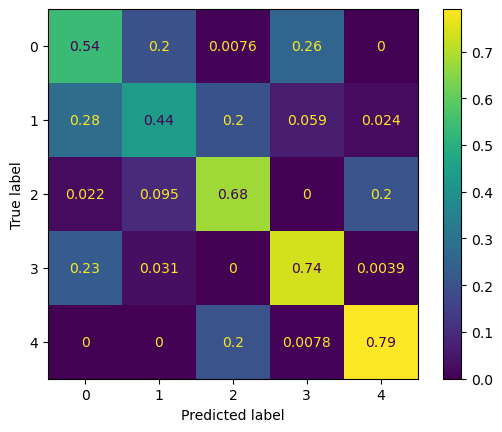

In [226]:
ConfusionMatrixDisplay.from_predictions(
    y_test_5,
    y_pred_lr_cl, # these are the predictions for lr_classifier, 
    normalize='true' 
)

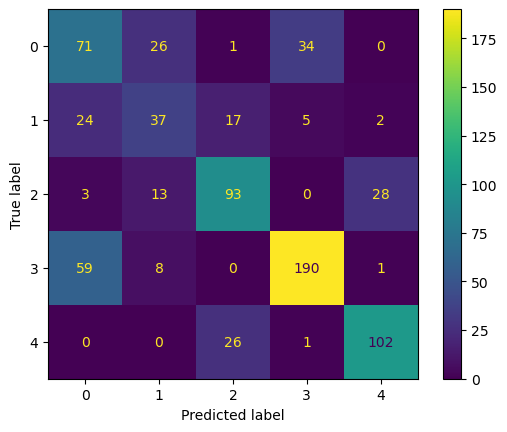

In [228]:
ConfusionMatrixDisplay.from_predictions(
    y_test_5,
    y_pred_lr_cl # these are the predictions for lr_classifier, 
)

### Discussion 

there must be some discussion here

### Manual inspection
Now I will manually inspect some of the worngly classified reviews to try to get a feeling of how wrong the model is and check if there is maybe some encoding problem. 

In [238]:
errors = X_test_lr_5.copy()

errors['actual'] = le_5.inverse_transform(y_test_5)
errors['predicted'] = le_5.inverse_transform(y_pred_lr_cl)

errors = errors[errors['actual'] != errors['predicted']]

In [246]:
errors[['review_body', 'actual', 'predicted']].head(20)

,review_body,actual,predicted
3559,Montreal - LHR. I love BA but sometimes they have an off-day and this was one of them. Crew not ready when passengers boarding - some still eating their crew food. Pre-flight everything seemed rushed with no newspapers or amenity kits offered. Flight itself was fine and food very good. Landing at LHR we were parked remotely. My husband had requested assistance and we were told to wait until all the other passengers had disembarked (which took 20 minutes) only to have to join a bus with no help at all. Needless to say no one on hand inside T5 and only by flagging down a passing buggy did we manage to get to Border Control. Just not great.,negative,neutral
3694,Flight from Heathrow to Toronto. Booked emergency exit seat for night flight home. Cost £55 but worth it. Overall was ok both ways except for awful breakfast prior to landing at Heathrow. A freezing muffin in a piece of plastic and a polystyrene cup of coffee. Not a cheap flight - better value with Air Transat club which costs about the same and is better in every way.,positive,neutral
3207,The last trip was in Nov to Washington flew first in the new A380 which is a great aircraft very spacious cabin and extremely quiet. Service and drinks choice fine but their food is always questionable. On the way out had the tasting menu which was good even had two dishes repeated but on the return chose the chicken in a mushroom sauce! This was disgusting and after two bites sent it back. This is not the first time BA's food has been suspect either their club Europe service to Gibraltar also serves up light cold snacks though charging up to £750 return for a 2.5hour flight. For those looking to fly BA the lounges aircraft and staff are good to go but the food needs to be improved.,very_positive,positive
3525,LHR-BSL-LHR A319's each way check/bag drop atT5 took ages around 40 min. Once checked in lounge and boarding good seat 15c enough time for a coffee and sandwich arrived a little late due to weather. Return similar flight experience same food very full flight bag drop at BSL very quick and very nice lounge. Departed a little late and arrived 20 min late otherwise good experience nice crew in both directions.,neutral,very_positive
762,Phoenix to Tel Aviv via London. The return from London to Phoenix was a nightmare. I want everyone to know that I sent a complaint 3 times but there is no one to talk to. This is not something that I am used to.,neutral,very_negative
1095,"London Heathrow to Brindisi. We weren’t expecting the long queue for Club Europe check-in, but mid-afternoon is apparently particularly busy in T5. Galleries South lounge was also teeming, but at least the filthy chairs had been replaced and there was a reasonable selection of hot and cold food. Group boarding was handled efficiently. The A321 was relatively new and clean, no pre-take-off drinks were offered. Departure was delayed by about 30 minutes but arrival was on time. The Club Europe section was unusually busy, with at least ten, fully occupied rows, including families with pre-school children. Despite the congestion and chaos, the food and drink service was handled efficiently, although the food was no better than the old World Traveller offering. It’s hard to see the point of BA’s short haul business class product when the experience is second rate.",negative,neutral
2782,Ground handling is not great at Bari but once on board was quickly forgotten. Great flight with attentive cabin crew. Delicious afternoon tea with unlimited Champagne. Very good experience.,positive,very_positive
1879,"In September 2016, I flew with British Airways in First from London to Kuala Lumpur on flight BA0033. Initial impressions were positive. The check-in was efficient with polite and friendly staff. The Concorde Room was a nice place to be. My First suite (2A) offered a good amount of comfort, space and privacy. Fast forward 12+ hours. Would I fly in British Airways First again? No. Would I fl

### Observation 

Apparently, many of the observations' labels from the excerpt above are wrong. It even seems that the model's prediction is more accurate that the label itself.  
Thus, the target feature overall_rating will be deeply examined again.  
Note: The overall_rating might express the opinion better even if it appears to not fully allign with the other features. 

In [254]:
#Check if there is a correlation between overall_rating and the mean value of the other rating columns 
# (note: this mean was already calculated and is stored in the variable calculated_mean)


from scipy.stats import spearmanr

reviews['rating_mean'] = calculated_mean
comparison_df = reviews[['overall_rating', 'rating_mean']].dropna()

spearman_corr, spearman_p = spearmanr(
    comparison_df['overall_rating'],
    comparison_df['rating_mean']
)

print(f"Spearman correlation: {spearman_corr:.3f} (p={spearman_p:.5f})")

Spearman correlation: 0.888 (p=0.00000)


In [268]:
reviews[rating_cols]

,overall_rating,seat_comfort,cabin_staff_service,ground_service,value_for_money,food&beverages,inflight_entertainment,wifi&connectivity
0,1.0,1.0,1.0,1.0,1.0,missing,missing,missing
1,3.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0
2,8.0,3.0,3.0,4.0,3.0,4.0,missing,missing
3,1.0,3.0,3.0,1.0,1.0,missing,missing,missing
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
3696,1.0,3.0,1.0,missing,3.0,2.0,missing,missing
3697,9.0,4.0,5.0,missing,3.0,4.0,missing,missing
3698,5.0,missing,missing,missing,4.0,missing,missing,missing
3699,4.0,1.0,3.0,missing,1.0,5.0,missing,missing


In [274]:
#Now I will examine the distribution of disagreement 

disagr_df = reviews[['overall_rating', 'rating_mean']].dropna().copy()

disagr_df['overall_norm'] = (disagr_df['overall_rating'] - 1) / 9
disagr_df['mean_norm'] = (disagr_df['rating_mean'] - 1) / 4

disagr_df['difference'] = (
    disagr_df['overall_norm']
    - disagr_df['mean_norm']
)

disagr_df['diff_n_scaled'] = disagr_df['overall_rating'] - disagr_df['rating_mean']

print(disagr_df['diff_n_scaled'].describe())
print(disagr_df['difference'].describe())

count    3696.000000
mean        1.952561
std         2.156456
min        -3.714286
25%         0.000000
50%         1.600000
75%         4.000000
max         8.500000
Name: diff_n_scaled, dtype: float64
count    3696.000000
mean       -0.030513
std         0.153451
min        -0.928571
25%        -0.111111
50%        -0.005556
75%         0.066667
max         0.875000
Name: difference, dtype: float64


### Discussion
The above two examinations show that overall_rating is indeed well-representative (with Spearmann = 0.888).  
The mean value of the differences is also very small (1.95 in points value and -0.03 in scaled ratings). This means that the disagreement between overall_rating and the other rating features is not drastic. On the other hand, there are extreme disagreement values (min = -3.71 points and max = 8.5 points), which will now be focused on.  
First, I will examine the proportion of this huge disagreement observations.  
Then, I will train the very same LR model on a dataset without the extreme disagreement observations to check if the metrics improve significantly. 

In [281]:
disagr_df['abs_difference'] = abs(disagr_df['difference'])

print((disagr_df['abs_difference'] > 0.2).mean())
print((disagr_df['abs_difference'] > 0.3).mean())
print((disagr_df['abs_difference'] > 0.4).mean())

0.16774891774891776
0.06818181818181818
0.021374458874458876


In [285]:
abs_diff = disagr_df['abs_difference']

for threshold in [0.2, 0.25, 0.3, 0.4]:
    proportion = (abs_diff > threshold).mean()
    count = (abs_diff > threshold).sum()

    print(
        f"Threshold > {threshold}: "
        f"{count} observations "
        f"({proportion:.2%} of the dataset)"
    )

Threshold > 0.2: 620 observations (16.77% of the dataset)
Threshold > 0.25: 344 observations (9.31% of the dataset)
Threshold > 0.3: 252 observations (6.82% of the dataset)
Threshold > 0.4: 79 observations (2.14% of the dataset)


### Retrain
Now the model will be retrained on a dataset without the observation with a difference greater than 0.25. This removes a little more than 9% of the reviews dataset

In [291]:
# Not a new model will be trained with a clean dataset with a threshold 0.25 for abs_difference 

reviews['overall_norm'] = (reviews['overall_rating'] - 1) / 9
reviews['mean_norm'] = (reviews['rating_mean'] - 1) / 4

reviews['abs_difference'] = abs(
    reviews['overall_norm']
    - reviews['mean_norm'])

In [293]:
clean_df = reviews[reviews['abs_difference'] <= 0.25]

In [296]:
# New label encoding encoding
le_5 = LabelEncoder()
y_51 = le_5.fit_transform(clean_df['sentiment_5'])

In [298]:
# Performs train test split again
X_lr_2 = clean_df[feature_columns_lr]

X_train_lr_51, X_test_lr_51, y_train_51, y_test_51 = train_test_split(
    X_lr_2, y_51, test_size=0.2, random_state=42, stratify=y_51)

In [305]:
lr_classifier_1 = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=5000))
])

lr_classifier_1.fit(X_train_lr_51, y_train_51)
y_pred_lr_cl_1 = lr_classifier_1.predict(X_test_lr_51)
    
print(classification_report(y_test_51, y_pred_lr_cl_1))

              precision    recall  f1-score   support

           0       0.62      0.59      0.61       123
           1       0.54      0.43      0.48        79
           2       0.74      0.82      0.78       131
           3       0.85      0.89      0.87       215
           4       0.85      0.84      0.84       123

    accuracy                           0.76       671
   macro avg       0.72      0.71      0.72       671
weighted avg       0.75      0.76      0.75       671



In [307]:
train_acc_lr_1 = accuracy_score(y_train_51, lr_classifier_1.predict(X_train_lr_51))
test_acc_lr_1 = accuracy_score(y_test_51, y_pred_lr_cl_1)

print(f"Train Accuracy: {train_acc_lr_1:.3f}")
print(f"Test Accuracy: {test_acc_lr_1:.3f}")

Train Accuracy: 0.887
Test Accuracy: 0.759


In [309]:
# А какво ще стане, ако тествам модела от окастрените данни върху неокастрените данни?
#Check how does the model perform on the uncleaned data 
y_pred_clean_model_bad_data = lr_classifier_1.predict(X_test_lr_5) 
print(classification_report(y_test_5, y_pred_clean_model_bad_data))


              precision    recall  f1-score   support

           0       0.64      0.77      0.70       132
           1       0.71      0.58      0.64        85
           2       0.75      0.88      0.81       137
           3       0.90      0.82      0.86       258
           4       0.92      0.85      0.88       129

    accuracy                           0.80       741
   macro avg       0.78      0.78      0.78       741
weighted avg       0.81      0.80      0.80       741



In [311]:
#Save the model
import joblib

joblib.dump(lr_classifier_1, "sentiment_classifier.joblib")

['sentiment_classifier.joblib']